In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("hr_attrition_data.csv")

In [3]:
df.head()

,EmployeeID,Age,Gender,Department,JobRole,Salary,YearsAtCompany,Overtime,JobSatisfaction,Attrition
0,E001,23,Male,HR,Manager,26200,1,No,2,No
1,E002,24,Female,IT,Analyst,27400,2,No,3,No
2,E003,25,Male,Finance,Associate,28600,3,Yes,4,No
3,E004,26,Female,Marketing,Specialist,29800,4,No,5,Yes
4,E005,27,Male,Sales,Executive,31000,5,No,1,No


In [4]:
# Check Dataset Shape
df.shape

(100, 10)

In [5]:
# Check Column Names
df.columns

Index(['EmployeeID', 'Age', 'Gender', 'Department', 'JobRole', 'Salary',
       'YearsAtCompany', 'Overtime', 'JobSatisfaction', 'Attrition'],
      dtype='str')

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   EmployeeID       100 non-null    str  
 1   Age              100 non-null    int64
 2   Gender           100 non-null    str  
 3   Department       100 non-null    str  
 4   JobRole          100 non-null    str  
 5   Salary           100 non-null    int64
 6   YearsAtCompany   100 non-null    int64
 7   Overtime         100 non-null    str  
 8   JobSatisfaction  100 non-null    int64
 9   Attrition        100 non-null    str  
dtypes: int64(4), str(6)
memory usage: 7.9 KB


In [7]:
# Statistical Summary
df.describe()

,Age,Salary,YearsAtCompany,JobSatisfaction
count,100.00000,100.000000,100.000000,100.000000
mean,33.14000,85600.000000,6.850000,3.000000
std,7.04677,34813.790371,4.243533,1.421338
min,22.00000,26200.000000,0.000000,1.000000
25%,27.00000,55900.000000,3.000000,2.000000
50%,33.00000,85600.000000,7.000000,3.000000
75%,39.00000,115300.000000,10.000000,4.000000
max,45.00000,145000.000000,14.000000,5.000000


In [8]:
# Check Missing Values
df.isnull().sum()

EmployeeID         0
Age                0
Gender             0
Department         0
JobRole            0
Salary             0
YearsAtCompany     0
Overtime           0
JobSatisfaction    0
Attrition          0
dtype: int64

In [10]:
# Unique Values in Each Category
print(df['Department'].unique())
print(df['JobRole'].unique())
print(df['Attrition'].unique())
print(df['Overtime'].unique())

<StringArray>
['HR', 'IT', 'Finance', 'Marketing', 'Sales']
Length: 5, dtype: str
<StringArray>
['Manager', 'Analyst', 'Associate', 'Specialist', 'Executive']
Length: 5, dtype: str
<StringArray>
['No', 'Yes']
Length: 2, dtype: str
<StringArray>
['No', 'Yes']
Length: 2, dtype: str


In [11]:
# Overall Attrition Rate

In [12]:
attrition_rate = (df['Attrition'].value_counts(normalize=True) * 100)

print(attrition_rate)

Attrition
No     75.0
Yes    25.0
Name: proportion, dtype: float64


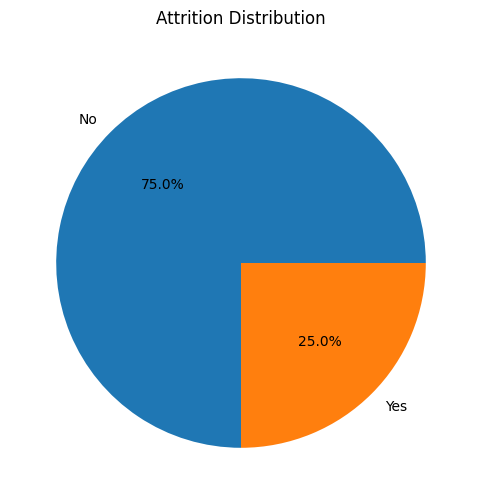

In [13]:
# Visualization
df['Attrition'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(6,6)
)

plt.title('Attrition Distribution')
plt.ylabel('')
plt.show()

In [14]:
# Department-wise Attrition

In [15]:
dept_attrition = pd.crosstab(
    df['Department'],
    df['Attrition']
)

print(dept_attrition)

Attrition   No  Yes
Department         
Finance     15    5
HR          15    5
IT          15    5
Marketing   15    5
Sales       15    5


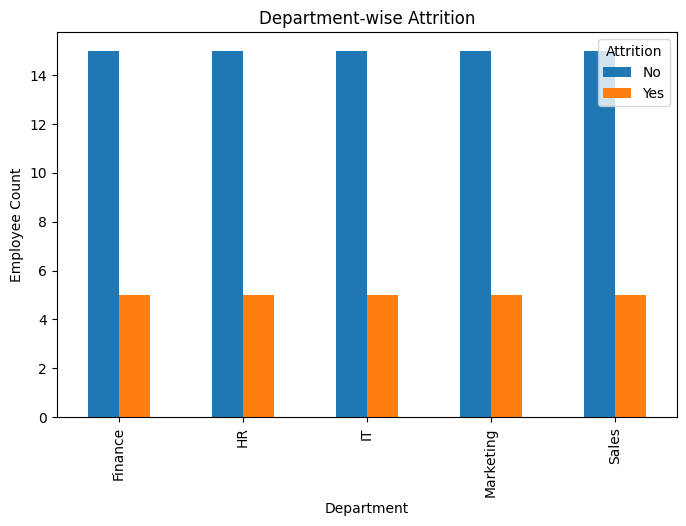

In [16]:
# Visualization
dept_attrition.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Department-wise Attrition')
plt.xlabel('Department')
plt.ylabel('Employee Count')
plt.show()

In [17]:
# Salary Analysis

In [18]:
df.groupby('Attrition')['Salary'].mean()

Attrition
No     85000.0
Yes    87400.0
Name: Salary, dtype: float64

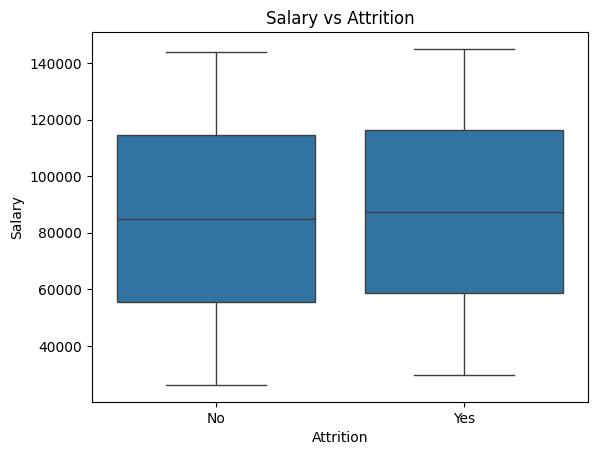

In [19]:
# Visualization
sns.boxplot(
    x='Attrition',
    y='Salary',
    data=df
)

plt.title('Salary vs Attrition')
plt.show()

In [20]:
# Overtime Analysis

In [21]:
pd.crosstab(
    df['Overtime'],
    df['Attrition']
)

Attrition,No,Yes
Overtime,,
No,50,17
Yes,25,8


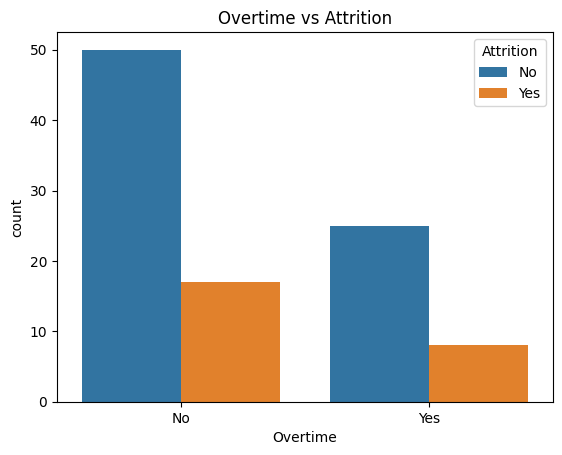

In [22]:
# Visualization
sns.countplot(
    x='Overtime',
    hue='Attrition',
    data=df
)

plt.title('Overtime vs Attrition')
plt.show()

In [23]:
# Job Satisfaction Analysis

In [24]:
pd.crosstab(
    df['JobSatisfaction'],
    df['Attrition']
)

Attrition,No,Yes
JobSatisfaction,,
1,15,5
2,15,5
3,15,5
4,15,5
5,15,5


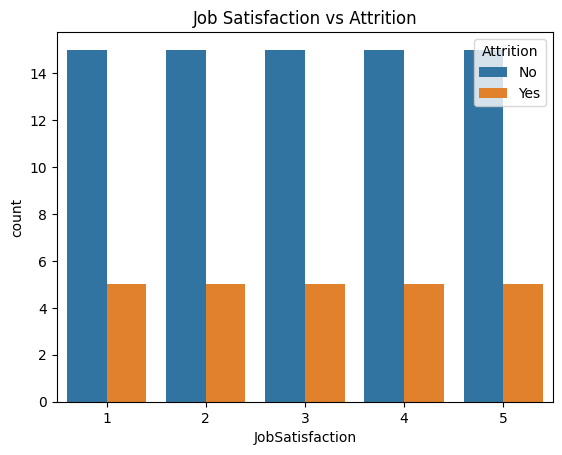

In [25]:
sns.countplot(
    x='JobSatisfaction',
    hue='Attrition',
    data=df
)

plt.title('Job Satisfaction vs Attrition')
plt.show()

In [26]:
# Mini KPI Dashboard

In [27]:
print("Total Employees:", len(df))
print("Employees Left:", len(df[df['Attrition']=='Yes']))
print("Employees Stayed:", len(df[df['Attrition']=='No']))
print("Average Salary:", round(df['Salary'].mean(),2))

Total Employees: 100
Employees Left: 25
Employees Stayed: 75
Average Salary: 85600.0


In [28]:
# Age vs Attrition

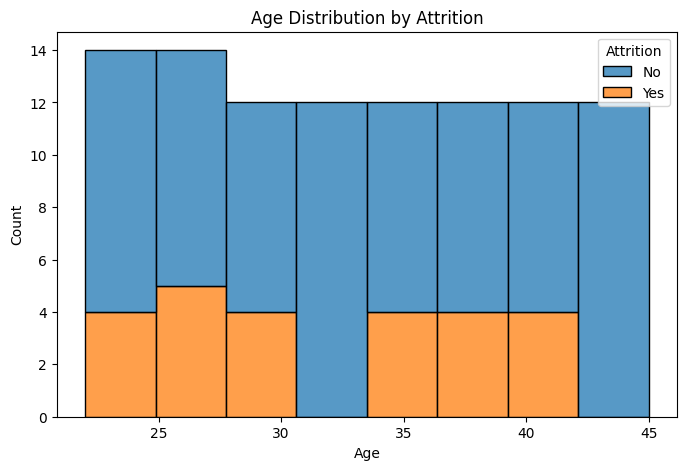

In [29]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x='Age',
    hue='Attrition',
    multiple='stack'
)

plt.title('Age Distribution by Attrition')
plt.show()

In [31]:
# . Salary Distribution

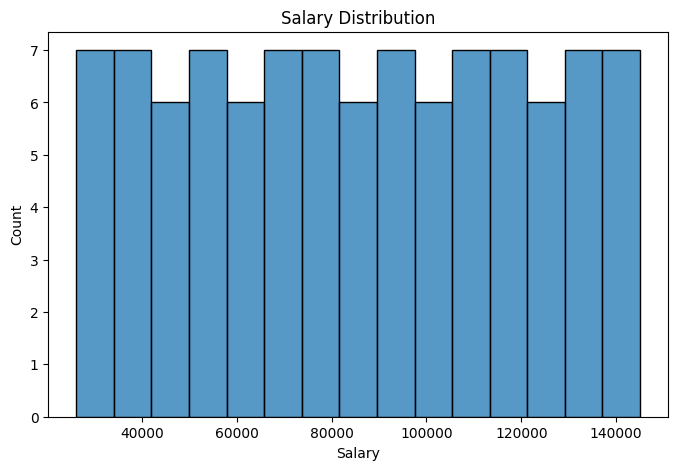

In [32]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['Salary'],
    bins=15
)

plt.title('Salary Distribution')
plt.show()

In [33]:
# Department-wise Average Salary

In [34]:
dept_salary = df.groupby('Department')['Salary'].mean()

print(dept_salary)

Department
Finance      85600.0
HR           83200.0
IT           84400.0
Marketing    86800.0
Sales        88000.0
Name: Salary, dtype: float64


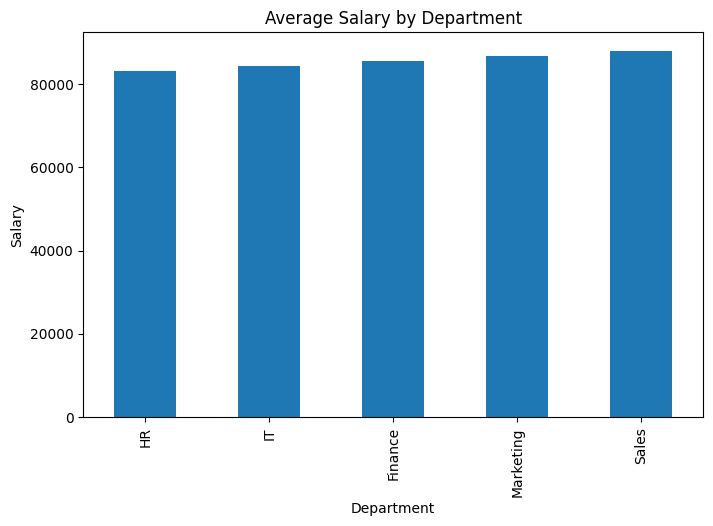

In [35]:
#visualization
dept_salary.sort_values().plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Average Salary by Department')
plt.ylabel('Salary')
plt.show()

In [36]:
# Years at Company Analysis

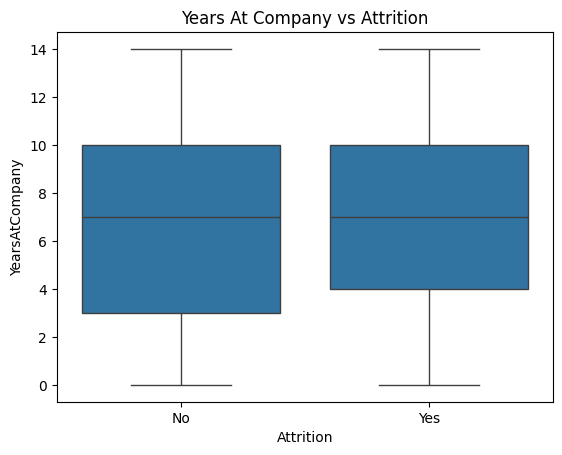

In [37]:
sns.boxplot(
    x='Attrition',
    y='YearsAtCompany',
    data=df
)

plt.title('Years At Company vs Attrition')
plt.show()

In [38]:
# BUSINESS FINDINGS

# 1. Attrition Rate = XX%

# 2. Highest Attrition Department:
#    __________

# 3. Overtime employees show:
#    Higher / Lower Attrition

# 4. Average Salary Difference:
#    Employees leaving vs staying

# 5. Job Satisfaction Impact:
#    Strong / Moderate / Weak